In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Bio
import Bio.Seq
import numpy as np
import seaborn as sns

## Import Dataset

In [2]:
df = pd.read_pickle("/Users/promero/Dropbox/projects/jared/GSF2636_Lewis_Pacbio/Fasta_Sequences_without_Indels/azid_activity.pkl")
df.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9941,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,8031,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,5729,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3147,3


In [3]:
# number of sequences
Nseq = len(df)
Nseq

960

In [4]:
# WildType Sequence
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
WT = Bio.Seq.Seq(WT_DNA).translate()
WT

Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*', HasStopCodon(ExtendedIUPACProtein(), '*'))

In [5]:
# Length of a sequence
N = len(df.iloc[0].sequence)
N

274

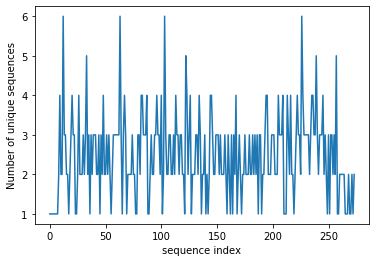

In [6]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence.str.get(i).unique()) for i in range(N)])
plt.plot(num_unique)
plt.xlabel("sequence index")
plt.ylabel("Number of unique sequences");

In [7]:
len(df.sequence.unique())

905

In [8]:
len(df)

960

In [9]:
# location of the first stop sequence
df["first_stop"] = df.sequence.str.find("*")
print((df.first_stop != (N-1)).sum())
# print out wherever we have a stop in the middle
df[df.first_stop != (N-1)]

33


,sequence,count,response,first_stop
14,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1425,3,122
8,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,200,1,84
25,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,57,1,84
96,MQHTYPAQLMRFGTAARAEHMTIAAATHALDADEADAIVMDIVPDG...,30,1,167
103,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,28,1,91
104,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,28,1,167
121,MQHTYPAQLMRFGTAARAEHKTIAAAIHALDADEADAIVMDIVPDG...,27,1,170
145,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVKDTVPDG...,24,1,167
160,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,22,1,214
31,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,24,0,160


In [10]:
df[df.sequence == WT]

,sequence,count,response,first_stop
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2,273
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1185,1,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,515,0,273


In [11]:
df_nostop = df[df.first_stop == (len(WT) -1)].drop(columns=['first_stop'])
df_nostop.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9941,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,8031,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,5729,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3147,3


In [12]:
# Replace non-unique sequences with their response category with the highest count
df_unique = df_nostop.sort_values('count', ascending=False).groupby('sequence').head(1).reset_index(drop=True)
df_unique.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16082,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,12035,2
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9704,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,4234,2


In [13]:
df_unique[["sequence", "response"]].groupby("response").count()

,sequence
response,
0,647
1,157
2,54
3,14


In [14]:
# Where is WT in this dataframe
# It should be at the top
df_unique[df_unique.sequence==WT]

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2


## Ordinal regression

In [15]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
import mord

In [16]:
design_cols = df_unique.sequence.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
#enc = OneHotEncoder(
#    drop=None, # don't drop columns 
#    sparse=False ) # setting to False for now

enc = OneHotEncoder()
OHE = enc.fit(design_cols)
X = OHE.transform(design_cols)
print(X.shape)
X

(872, 658)


<872x658 sparse matrix of type '<class 'numpy.float64'>'
	with 238928 stored elements in Compressed Sparse Row format>

In [17]:
enc.get_feature_names().size

658

In [18]:
mutations =  [WT[int(f[1:-2])]+f[1:-2]+f[-1] for f in enc.get_feature_names()]

In [19]:
y = df_unique.response.to_numpy()

In [20]:
# Try out model with alpha = 1.0
model = mord.LogisticAT(alpha=1.0)
model.fit(X, y)
model.score(X, y)

-0.143348623853211

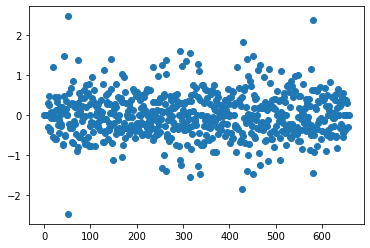

In [21]:
best_coefs = model.coef_
plt.plot(best_coefs, 'o')

In [22]:
best_results = pd.DataFrame({'feature':mutations, 'coef':best_coefs})

In [23]:
best_results.sort_values('coef', ascending=False).head(10)

,feature,coef
52,A25T,2.468445
581,L238Q,2.374119
429,L181P,1.836654
293,K122I,1.597748
314,Y130H,1.540860
451,G191S,1.474100
42,M20T,1.468862
437,G185D,1.399996
144,K63E,1.390249
262,R110C,1.387474


In [24]:
def show_design_response(col_num):
    return pd.DataFrame({'aa':design_cols[col_num], 'response':y}).groupby(['aa', 'response']).size()
show_design_response(33)

aa  response
D   0             1
    1             1
    2             1
E   0           643
    1           154
    2            51
    3            14
G   0             3
K   2             2
V   1             2
dtype: int64

In [25]:
show_design_response(191)

aa  response
G   0           644
    1           157
    2            54
    3            12
S   0             3
    3             2
dtype: int64

In [26]:
best_results.sort_values('coef', ascending=True).head(10)

,feature,coef
51,A25A,-2.468447
428,L181L,-1.836656
315,Y130Y,-1.540861
337,R139R,-1.477869
450,G191G,-1.474102
580,L238L,-1.439825
438,G185G,-1.399998
263,R110R,-1.387475
255,R107R,-1.326995
332,A137T,-1.263497


In [27]:
show_design_response(238)

aa  response
L   0           645
    1           157
    2            54
    3            11
Q   3             3
V   0             2
dtype: int64

In [28]:
show_design_response(214)

aa  response
E   0           647
    1           156
    2            52
    3            14
G   1             1
    2             2
dtype: int64

In [29]:
WTscore = OHE.transform([WT,]) * model.coef_
AAs = 'ACDEFGHIKLMNPQRSTVWY'
score = pd.DataFrame([[np.nan] * len(WT) for a in AAs],index=list(AAs))
ms = []

In [30]:
for mut in mutations:
    WTres = mut[0]
    pos = int(mut[1:-1])
    mut_res = mut[-1]
    if WTres==mut_res:
        score.loc[WTres,pos] = 0
    else:
        mutant_seq = list(WT)
        mutant_seq[pos] = mut_res
        mut_score = OHE.transform([mutant_seq,]) * model.coef_
        diff = mut_score - WTscore
        score.loc[mut_res,pos] = diff[0]
        ms.append((mut,diff[0]))

In [31]:
ms = pd.DataFrame(ms,columns = ['mutation','score'])
ms.sort_values('score', ascending=False).head(10)

,mutation,score
26,A25T,4.936893
342,L238Q,3.813944
247,L181P,3.673311
184,Y130H,3.081721
259,G191S,2.948203
252,G185D,2.799994
152,R110C,2.774949
171,K122I,2.730002
147,R107C,2.580657
196,R139C,2.573946


In [32]:
ms.sort_values('score', ascending=True).head(10)

,mutation,score
194,A137T,-2.526992
269,D196E,-2.495752
240,R175H,-2.134964
181,I126V,-2.104788
253,A186T,-1.976399
135,C100R,-1.821916
136,C100W,-1.760573
179,I126F,-1.739426
275,E200K,-1.607603
361,I247V,-1.581184


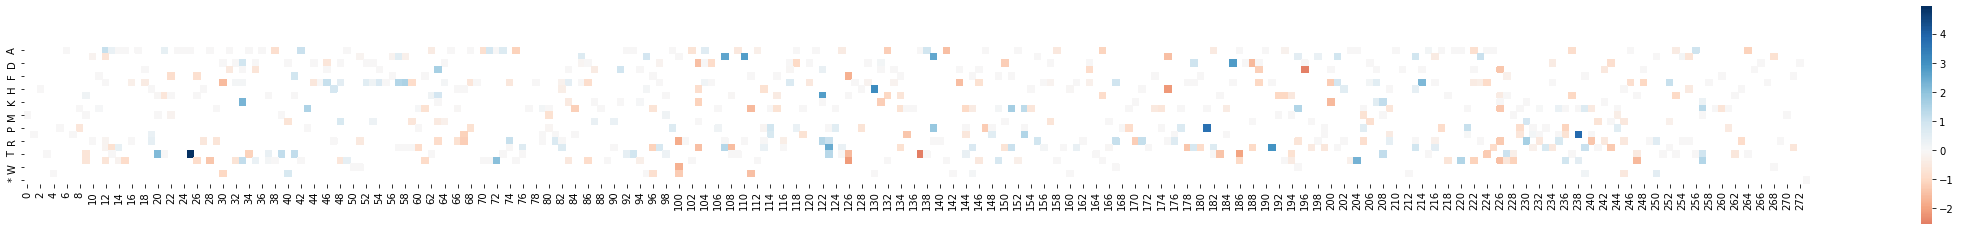

In [33]:
plt.figure(figsize=(40,4))
fig = sns.heatmap(score, center = 0, cmap = 'RdBu', square = True)
plt.savefig('score_azid_heatmap.png', dpi=500)

In [34]:
# get a site-wise score for plotting onto structure 
pos_score = []
for pos in score:
    not_nan = [s for s in score[pos] if not np.isnan(s)]
    mx = max([(abs(s),s) for s in not_nan])[1] #max magnitude score 
    pos_score.append(mx)
    
pos_score = pos_score[:-1] # remove stop codon

In [35]:
# scale for plotting 
scaled = np.array(pos_score)
scaled[scaled>0] = scaled[scaled>0]/scaled.max() # rescale above 0 between 0 and 1
#scaled[scaled<-2000] = -2000 # set min floor
scaled[scaled<0] = scaled[scaled<0]/(-1*scaled.min()) # rescale below 0 to between -1 and 0
scaled = 100*(scaled - scaled.min())/(scaled.max()-scaled.min()) # rescale everything between 0 and 100

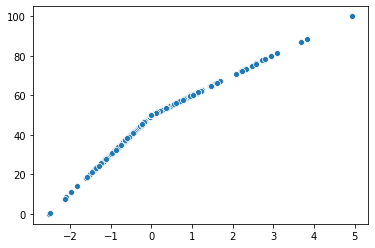

In [36]:
sns.scatterplot(pos_score,scaled)

In [37]:
pdb = open('3w20.pdb').read().strip().split('\n')
pdb = [l for l in pdb if len(l)>30 and (l[:6]=='HETATM' or l[:6].strip()=='ATOM') and l[21]=='A']
pdb = [l for l in pdb if l[17:20]!='HOH']
pdb = [l for l in pdb if l[17:20]!=' ZN']

In [38]:
tempFactor = dict((i+1,scaled[i]) for i in range(len(scaled)))
new_pdb = ''
for line in pdb:
    res_num = int(line[22:26])
    tf = ('%0.2f'%(tempFactor[res_num])).rjust(6) # format temp factor for PDB
    new_pdb+=line[:60]+tf+'\n'
    
open('SadH_azid_activity_mapped.pdb','w').write(new_pdb)

134268